# Activation Functions: Why Neurons Need a Gradient to Follow

*Making perceptrons trainable by gradient descent.*

In [Lesson 2](02_Perceptrons.ipynb) we built a perceptron out of a weighted
sum plus a **step activation function**, and hit two walls:

1. We couldn't train it with the gradient descent from
   [Lesson 1](01_GradientDescent.ipynb) — we had to invent a separate,
   mistake-counting rule instead.
2. Even that rule could never learn **XOR**.

This lesson explains *why* the first wall exists, fixes it — and then shows
that fixing it does **not**, by itself, get us past the second wall. By the
end you will be able to:

1. Explain what it means for a function to be **differentiable**, and
   recognize the two ways a function can fail to be.
2. Explain why an activation function used inside a network trained by
   gradient descent needs to be differentiable.
3. Describe the **sigmoid** and **ReLU** activation functions and their
   derivatives.
4. Train a single neuron with gradient descent itself (not the perceptron
   rule) — and confirm that a smoother activation still can't solve XOR.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Recap: a machine that couldn't slide downhill

Gradient descent, from Lesson 1, is one idea, repeated:

$$ x_{\text{new}} = x_{\text{old}} - (\text{learning rate}) \times \text{slope at } x_{\text{old}} $$

It only works if there **is** a slope to measure at every point along the
way. The step activation function from Lesson 2 is flat (slope zero)
everywhere except at one point, where it jumps straight up. There is
essentially nothing for gradient descent to grab onto — which is exactly why
Lesson 2 had to train its perceptron with a different rule (compare the
prediction to the target and nudge the weights) instead of gradient descent.

To use gradient descent directly on a neuron — and, eventually, to train
*networks* of neurons with an algorithm called **backpropagation** (teased in
Lesson 2's history table, invented 1986) — we need an activation function
with a well-defined, useful slope almost everywhere. Let's pin down exactly
what that means.


## 2. What does "having a slope" really mean?

Lesson 1 treated `gradient(x)` as a machine that reports the steepness of a
curve at a point. We can build that machine ourselves without any calculus,
just by zooming in: take one small step forward and one small step backward,
see how much the height changed, and divide by the distance travelled. This
is called a **numerical (finite-difference) derivative**.


In [2]:
def numerical_slope(f, x, h=1e-4):
    "Estimate the slope of f at x from a tiny step forward and backward."
    return (f(x + h) - f(x - h)) / (2 * h)


def f_smooth(x):
    return x**2


print(f"{'x':>6} {'numerical slope':>16} {'exact slope (2x)':>18}")
for x0 in [-2, 0, 3]:
    estimate = numerical_slope(f_smooth, x0)
    exact = 2 * x0
    print(f"{x0:>6} {estimate:>16.4f} {exact:>18.4f}")

     x  numerical slope   exact slope (2x)
    -2          -4.0000            -4.0000
     0           0.0000             0.0000
     3           6.0000             6.0000


For $y = x^2$ — the same "practice hill" from Lesson 1 — the numerical
estimate matches the exact slope $2x$ almost perfectly, no matter which point
we check. That's what it means for a function to be **differentiable** at a
point: zoom in close enough, and it looks like a straight line with one,
well-defined steepness. A function that is differentiable *everywhere* gives
gradient descent a usable slope no matter where it currently stands.

Not every function is this well-behaved. Let's go looking for trouble.


## 3. Two ways a function can lack a slope

### Corners

Consider $y = |x|$ — a perfectly ordinary-looking "V" shape. Let's run our
numerical-slope machine on it at the point of the V, $x = 0$.


In [3]:
def f_corner(x):
    return np.abs(x)


print("Central-difference estimate at the corner of |x| (x = 0):")
for h in [0.1, 0.01, 0.001]:
    print(f"  h = {h}: estimate = {numerical_slope(f_corner, 0, h):.4f}")

Central-difference estimate at the corner of |x| (x = 0):
  h = 0.1: estimate = 0.0000
  h = 0.01: estimate = 0.0000
  h = 0.001: estimate = 0.0000


Every estimate says **0** — but look at the picture below and you can see the
corner clearly isn't flat. The trick that worked for the smooth curve just
backfired: stepping the same tiny distance forward and backward happens to
average the V's two sides (slopes $-1$ and $+1$) into a misleading zero. To
actually catch a corner, we have to check each side **separately**:


In [4]:
print("Approaching the corner from the left and from the right:")
print(f"{'h':>10} {'left slope':>12} {'right slope':>12}")
for h in [0.1, 0.01, 0.001, 0.0001]:
    left_slope = (f_corner(0) - f_corner(0 - h)) / h
    right_slope = (f_corner(0 + h) - f_corner(0)) / h
    print(f"{h:>10} {left_slope:>12.4f} {right_slope:>12.4f}")

Approaching the corner from the left and from the right:
         h   left slope  right slope
       0.1      -1.0000       1.0000
      0.01      -1.0000       1.0000
     0.001      -1.0000       1.0000
    0.0001      -1.0000       1.0000


No matter how small `h` gets, the left side insists the slope is $-1$ and the
right side insists it's $+1$. They never agree, so there is no single slope
at $x = 0$ — the function is **not differentiable** there. This is a
**corner**: two straight edges meeting at different angles.

### Jumps

The step function from Lesson 2 has a different, more severe problem: an
actual **jump** in height, not just a change in direction.


In [5]:
def step(z):
    "Step activation: outputs 1 if z >= 0, otherwise 0."
    return np.where(z >= 0, 1, 0)


print("Central-difference estimate at the jump of step(z) (z = 0):")
for h in [0.1, 0.01, 0.001, 0.0001]:
    estimate = numerical_slope(step, 0, h)
    print(f"  h = {h}: estimate = {estimate:.1f}")

Central-difference estimate at the jump of step(z) (z = 0):
  h = 0.1: estimate = 5.0
  h = 0.01: estimate = 50.0
  h = 0.001: estimate = 500.0
  h = 0.0001: estimate = 5000.0


This time the estimate doesn't settle down at all — it grows without bound as
`h` shrinks (5, 50, 500, 5000, ...). Squeezing the same finite jump into a
smaller and smaller window makes it look steeper and steeper, forever. The
slope isn't just ambiguous here, it's **unbounded** — undefined in an even
more drastic way than the corner in $|x|$.


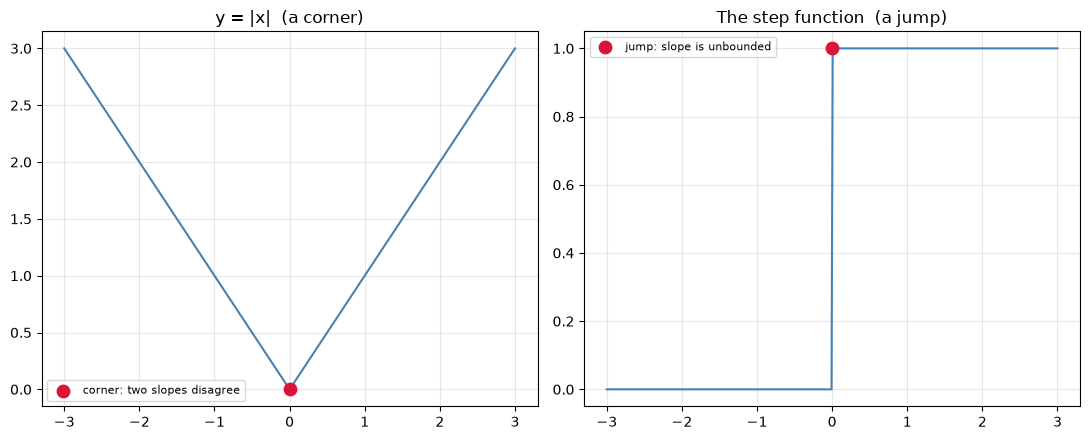

In [ ]:
x = np.linspace(-3, 3, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(x, np.abs(x), color="steelblue")
ax1.scatter([0], [0], color="crimson", zorder=5, s=80, label="corner: two slopes disagree")
ax1.set_title("y = |x|  (a corner)")
ax1.legend(fontsize=8)

ax2.plot(x, step(x), color="steelblue")
ax2.scatter([0], [1], color="crimson", zorder=5, s=80, label="jump: slope is unbounded")
ax2.set_title("The step function  (a jump)")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Why activation functions must be differentiable

Put this together with Lesson 1's update rule. If the slope at your current
position is exactly **0** almost everywhere (the step function), then

$$ x_{\text{new}} = x_{\text{old}} - \text{lr} \times 0 = x_{\text{old}} $$

— nothing ever moves, regardless of the learning rate. And right at the one
point where the step function *does* change, the slope isn't a small number
gradient descent could use — it's unbounded. Either way, there is no usable
downhill direction. That is the precise reason Lesson 2 couldn't reuse
gradient descent and had to invent the mistake-counting perceptron rule
instead.

Real neural networks — stacks of many neurons — are trained with an
algorithm called **backpropagation**, which computes the loss's slope with
respect to *every* weight by multiplying slopes together, layer by layer,
using the chain rule (the same "how does A affect B affect C" idea, applied
many times in a row). If even one neuron's activation function has a slope
that is undefined or always zero, that chain of multiplication breaks, and no
learning signal can pass through it.

**So: any activation function used inside a network trained by gradient
descent needs to be differentiable — with a slope that is usually well
defined and non-zero.** The step function fails this test. Let's meet two
functions that pass it.


## 5. Sigmoid: a smooth stand-in for the step

The **sigmoid** function squashes any real number into the range $(0, 1)$,
with a smooth S-shaped transition instead of a sudden jump:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$


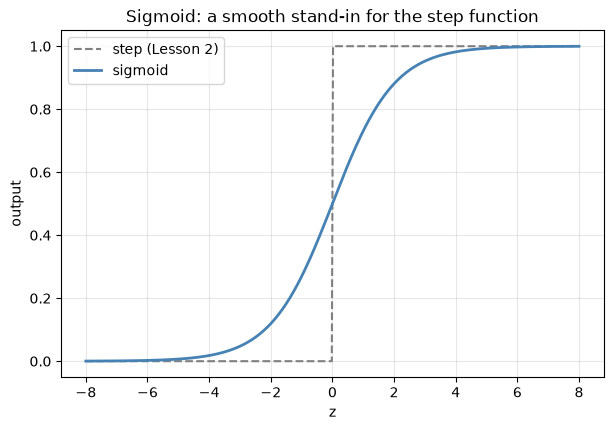

In [7]:
def sigmoid(z):
    "Smoothly squashes any real number into the range (0, 1)."
    z = np.clip(z, -500, 500)  # avoid overflow warnings for very large |z|
    return 1 / (1 + np.exp(-z))


def sigmoid_grad(z):
    "The slope of the sigmoid function at z."
    s = sigmoid(z)
    return s * (1 - s)


z = np.linspace(-8, 8, 400)

plt.plot(z, step(z), "--", color="gray", label="step (Lesson 2)")
plt.plot(z, sigmoid(z), color="steelblue", linewidth=2, label="sigmoid")
plt.xlabel("z")
plt.ylabel("output")
plt.title("Sigmoid: a smooth stand-in for the step function")
plt.legend()
plt.show()

It has the same overall shape as the step function — small $z$ maps near 0,
large $z$ maps near 1 — but the transition between them is gradual, so a
slope exists *everywhere*. Let's check our formula for that slope against the
numerical-slope machine from Section 2.


     z  numerical slope   formula s(1-s)
    -4          0.01766          0.01766
    -1          0.19661          0.19661
     0          0.25000          0.25000
     1          0.19661          0.19661
     4          0.01766          0.01766


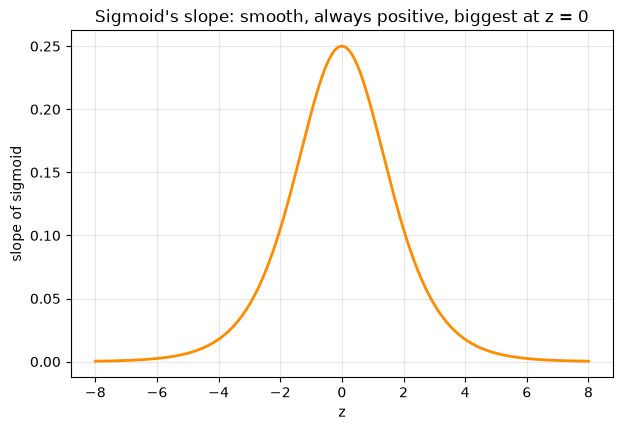

In [8]:
print(f"{'z':>6} {'numerical slope':>16} {'formula s(1-s)':>16}")
for z0 in [-4, -1, 0, 1, 4]:
    numerical = numerical_slope(sigmoid, z0)
    formula = sigmoid_grad(z0)
    print(f"{z0:>6} {numerical:>16.5f} {formula:>16.5f}")

plt.plot(z, sigmoid_grad(z), color="darkorange", linewidth=2)
plt.xlabel("z")
plt.ylabel("slope of sigmoid")
plt.title("Sigmoid's slope: smooth, always positive, biggest at z = 0")
plt.show()

The slope is small but never quite zero, everywhere — that's exactly what
gradient descent needs. (It does get very close to zero far from the middle,
which is a real practical headache called the *vanishing gradient problem* —
a story for a later lesson.)


## 6. ReLU: a cheap, popular alternative

**ReLU** ("Rectified Linear Unit") is almost embarrassingly simple: pass
positive numbers through unchanged, and clip everything negative to zero.

$$ \text{ReLU}(z) = \max(0, z) $$


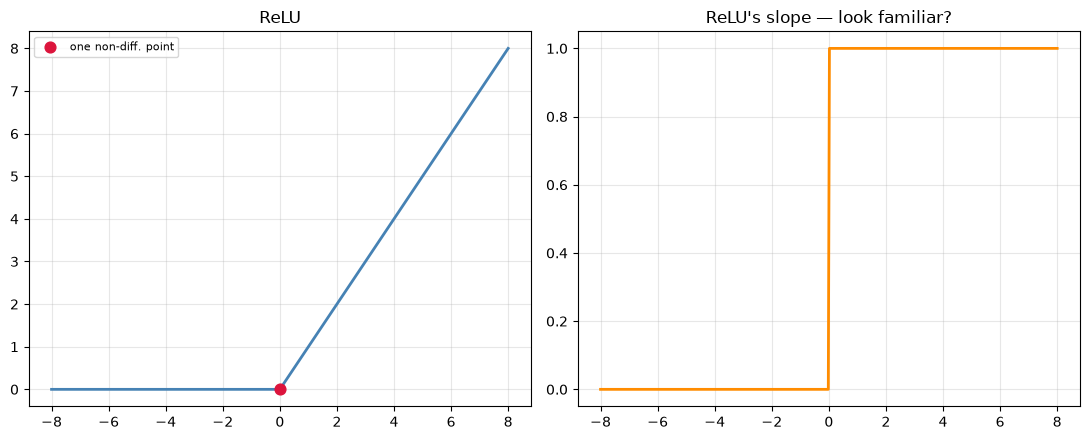

In [9]:
def relu(z):
    "Outputs z if positive, otherwise 0."
    return np.maximum(0, z)


def relu_grad(z):
    "The slope of ReLU: 1 where z > 0, 0 where z <= 0 (by convention)."
    return np.where(z > 0, 1.0, 0.0)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(z, relu(z), color="steelblue", linewidth=2)
ax1.scatter([0], [0], color="crimson", zorder=5, s=60, label="one non-diff. point")
ax1.set_title("ReLU")
ax1.legend(fontsize=8)

ax2.plot(z, relu_grad(z), color="darkorange", linewidth=2)
ax2.set_title("ReLU's slope — look familiar?")
plt.tight_layout()
plt.show()

ReLU's slope is exactly the step function from Lesson 2! The crucial
difference is *what role it plays*: it's no longer the activation itself
(which is what made the step function unusable), it's the activation's
**derivative** — and it is only ill-defined at a single point, $z = 0$,
rather than being flat across the entire number line.

That single point is still a genuine corner, though — let's confirm it with
the numerical-slope machine.


In [10]:
print(f"{'z':>8} {'numerical slope':>16} {'formula':>10}")
for z0 in [-2, -0.001, 0, 0.001, 2]:
    print(f"{z0:>8} {numerical_slope(relu, z0):>16.4f} {float(relu_grad(z0)):>10.4f}")

       z  numerical slope    formula
      -2           0.0000     0.0000
  -0.001           0.0000     0.0000
       0           0.5000     0.0000
   0.001           1.0000     1.0000
       2           1.0000     1.0000


Away from zero, the numerical estimate and the formula agree perfectly. But
exactly at $z = 0$ they disagree: the symmetric numerical trick reports
**0.5** (the average of ReLU's left slope, 0, and right slope, 1), while our
formula's convention reports **0.0**. Both are defensible — that's precisely
what "no single slope exists here" looks like. In practice this single point
is a coincidence that almost never happens exactly, so it costs us nothing:
ReLU is differentiable everywhere it actually matters, which is already a
huge improvement over the step function.


## 7. Gradient descent finally gets to train a neuron

Now that our neuron has a real slope, we can go back to using Lesson 1's
gradient descent directly — no separate mistake-counting rule needed. The
loss is the same **mean squared error** from the line-fitting demo in Lesson
1, just wrapped around a neuron's prediction $\hat{y} = \text{activation}(z)$
instead of a bare line:

$$ L(w, b) = \frac{1}{n}\sum_{i=1}^{n} \bigl(\text{activation}(z_i) - y_i\bigr)^2
\qquad z_i = \mathbf{w}\cdot\mathbf{x}_i + b $$

Computing its slope needs one extra multiplication compared to Lesson 1: the
activation function's *own* slope, chained on. (This is a one-neuron preview
of backpropagation — the general version, for whole networks, is a later
lesson.) We won't derive it, just use it, the same way Lesson 1 used the MSE
gradient formulas without deriving them:


In [ ]:
def train_neuron(
    inputs,
    labels,
    activation,
    activation_grad,
    learning_rate=0.5,
    n_epochs=3000,
    seed=0,
):
    "Train a single neuron with gradient descent (all examples at once, each epoch)."
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, size=inputs.shape[1])
    b = 0.1
    loss_history = []

    for _ in range(n_epochs):
        z = inputs @ w + b
        pred = activation(z)
        error = pred - labels
        loss_history.append(np.mean(error**2))

        dz = (2 * error * activation_grad(z)) / len(labels)  # chain rule: loss -> activation -> z
        dw = inputs.T @ dz
        db = np.sum(dz)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, loss_history

Let's throw the same AND and OR gates from Lesson 2 at it, and see whether
plain gradient descent can now do the job on its own.


AND -- learned w = [5.13497298 5.13497297], b = -7.797, final loss = 0.00364
OR  -- learned w = [5.84537802 5.84535004], b = -2.673, final loss = 0.00185


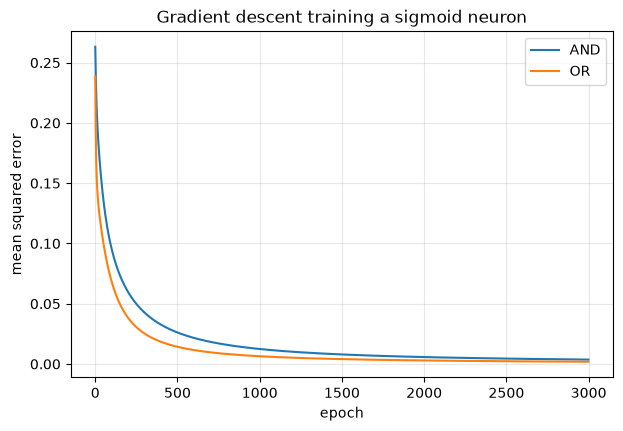

In [12]:
# All four possible combinations of two binary inputs (same data as Lesson 2)
inputs = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ]
)

and_labels = np.array([0, 0, 0, 1])
or_labels = np.array([0, 1, 1, 1])
xor_labels = np.array([0, 1, 1, 0])

w_and, b_and, loss_and = train_neuron(inputs, and_labels, sigmoid, sigmoid_grad)
w_or, b_or, loss_or = train_neuron(inputs, or_labels, sigmoid, sigmoid_grad)

print(f"AND -- learned w = {w_and}, b = {b_and:.3f}, final loss = {loss_and[-1]:.5f}")
print(f"OR  -- learned w = {w_or}, b = {b_or:.3f}, final loss = {loss_or[-1]:.5f}")

plt.plot(loss_and, label="AND")
plt.plot(loss_or, label="OR")
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Gradient descent training a sigmoid neuron")
plt.legend()
plt.show()

The loss drops to (nearly) zero for both gates, the same way it did for the
line-fitting demo in Lesson 1 — this time with a differentiable neuron
instead of a differentiable line. Here's the learned AND boundary, drawn the
same way as Lesson 2, but now shaded by the neuron's smooth output instead of
a hard 0/1 decision.


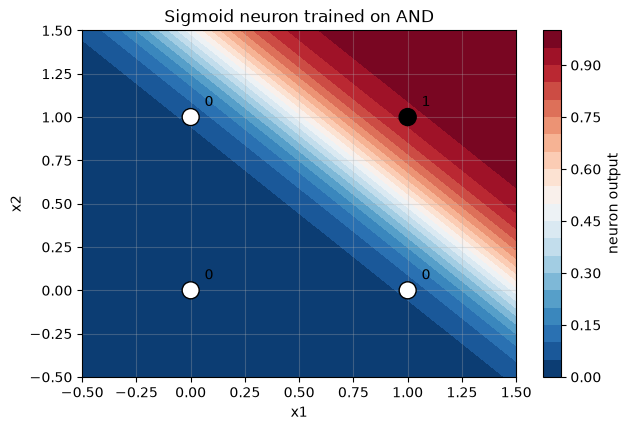

In [ ]:
def plot_decision_surface(w, b, activation, inputs, labels, title, ax=None):
    "Shade the input space by the neuron's output, and scatter the 4 gate points."
    if ax is None:
        _, ax = plt.subplots()

    grid = np.linspace(-0.5, 1.5, 200)
    X1, X2 = np.meshgrid(grid, grid)
    Z = activation(w[0] * X1 + w[1] * X2 + b)

    mesh = ax.contourf(X1, X2, Z, levels=20, cmap="RdBu_r")
    plt.colorbar(mesh, ax=ax, label="neuron output")

    colors = np.where(labels == 1, "black", "white")
    ax.scatter(inputs[:, 0], inputs[:, 1], c=colors, s=150, zorder=3, edgecolor="black")
    for (x1, x2), label in zip(inputs, labels):
        ax.annotate(
            str(label),
            (x1, x2),
            textcoords="offset points",
            xytext=(10, 8),
            color="black",
        )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    return ax


plot_decision_surface(w_and, b_and, sigmoid, inputs, and_labels, "Sigmoid neuron trained on AND")
plt.show()

## 8. ReLU learns the same gates

Let's confirm ReLU works too. One wrinkle: `train_neuron` starts from small
*random* weights rather than zero, on purpose. If it started at exactly
`w = 0, b = 0`, every input would produce `z = 0`, and ReLU's slope at `z = 0`
is (by our convention) 0 — gradient descent would be stuck before it even
took a step. This is a real phenomenon in practice, called a **dead
neuron**, and starting from small random numbers is one common way to avoid
it.


AND -- w = [1. 1.], b = -1.000, final loss = 0.00000


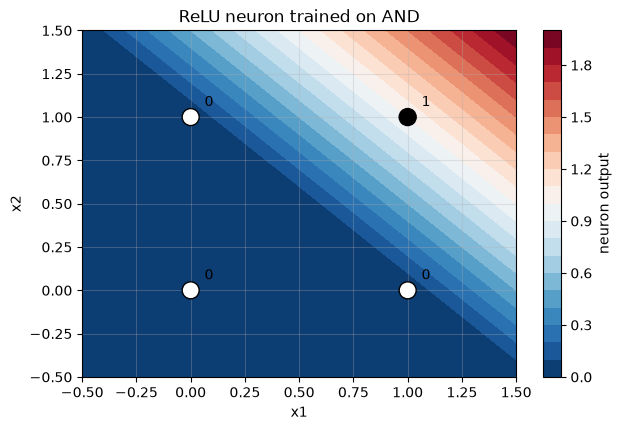

In [ ]:
w_and_r, b_and_r, loss_and_r = train_neuron(inputs, and_labels, relu, relu_grad, learning_rate=0.3)

print(f"AND -- w = {w_and_r}, b = {b_and_r:.3f}, final loss = {loss_and_r[-1]:.5f}")

plot_decision_surface(w_and_r, b_and_r, relu, inputs, and_labels, "ReLU neuron trained on AND")
plt.show()

Both smooth activations, trained purely by gradient descent, do exactly what
Lesson 2's perceptron rule did by hand-counted mistakes — but now using the
same downhill-walking algorithm from Lesson 1. That was wall #1. On to wall
#2.


## 9. Same shape, same limit: XOR again

Before running any code, notice something about *both* sigmoid and ReLU:
they are **monotonic** — bigger $z$ never produces a smaller output. That
means "the neuron fires" (output above some threshold, like sigmoid's 0.5 or
ReLU's 0) happens *exactly* when $z$ itself is above some fixed number. And
$z = \mathbf{w}\cdot\mathbf{x} + b$ is a straight line, no matter which
activation is bolted on afterward.

**A smoother activation changes how gently the neuron transitions between
"off" and "on" — and, crucially, whether gradient descent can train it at
all — but it does not change the shape of the boundary between them.** It's
still a straight line. That's exactly what defeated the perceptron in Lesson
2, and the argument above says it will defeat any single neuron, no matter
its activation. Let's watch it happen anyway.


Sigmoid on XOR -- loss = 0.25000  (vs. AND's 0.00364)
ReLU on XOR    -- loss = 0.25000  (vs. AND's 0.00000)


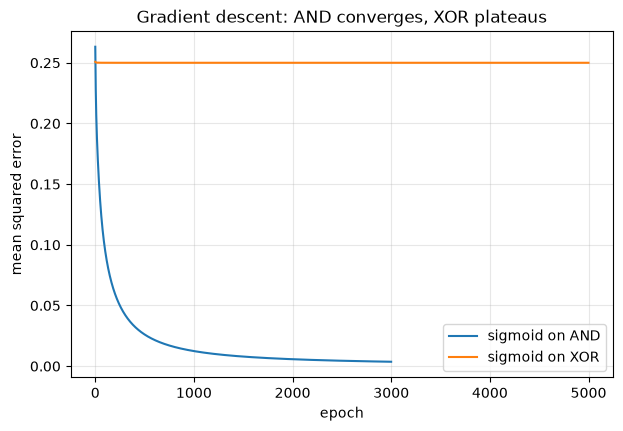

In [ ]:
w_xor, b_xor, loss_xor = train_neuron(inputs, xor_labels, sigmoid, sigmoid_grad, n_epochs=5000)
w_xor_r, b_xor_r, loss_xor_r = train_neuron(inputs, xor_labels, relu, relu_grad, learning_rate=0.3, n_epochs=5000)

print(f"Sigmoid on XOR -- loss = {loss_xor[-1]:.5f}  (vs. AND's {loss_and[-1]:.5f})")
print(f"ReLU on XOR    -- loss = {loss_xor_r[-1]:.5f}  (vs. AND's {loss_and_r[-1]:.5f})")

plt.plot(loss_and, label="sigmoid on AND")
plt.plot(loss_xor, label="sigmoid on XOR")
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Gradient descent: AND converges, XOR plateaus")
plt.legend()
plt.show()

Unlike the step-function perceptron in Lesson 2 (whose mistake count bounced
around forever), a differentiable neuron's loss glides smoothly downward and
then **settles at a plateau well above zero** — gradient descent is working
exactly as designed, faithfully finding the best possible straight-line
boundary. It just isn't good enough, because no straight line is. Here's what
that "best it can do" looks like for both activations:


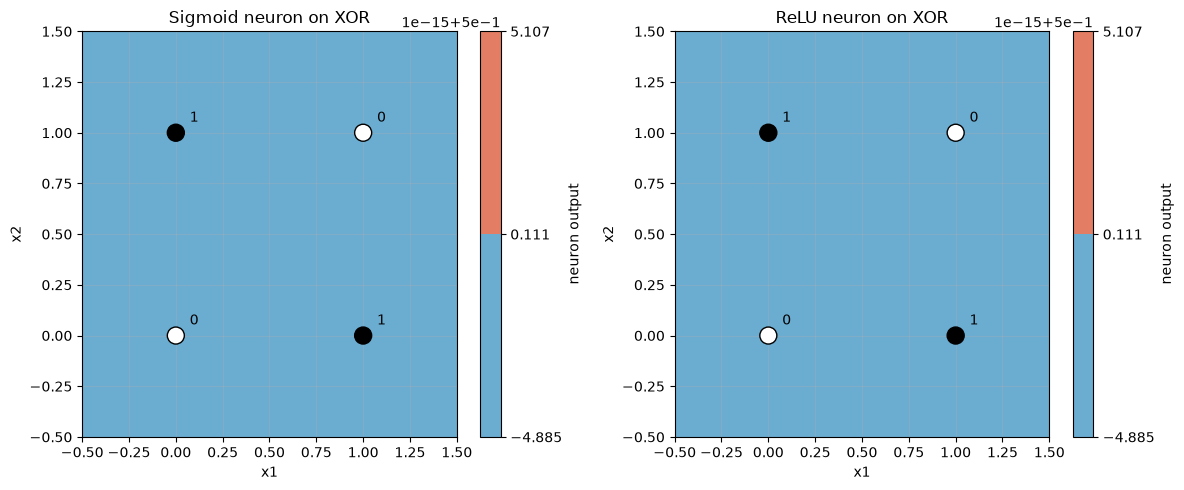

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_surface(w_xor, b_xor, sigmoid, inputs, xor_labels, "Sigmoid neuron on XOR", ax=axes[0])
plot_decision_surface(w_xor_r, b_xor_r, relu, inputs, xor_labels, "ReLU neuron on XOR", ax=axes[1])
plt.tight_layout()
plt.show()

Both shadings are perfectly smooth, and both are still fundamentally a
gradient sliding across the plane from one side of a straight line to the
other — there's no way to bend either one around to put the two black dots
(label 1) on one side and the two white dots (label 0) on the other. That
confirms Section 9's argument: swapping the activation function fixed
**trainability**, but it did nothing for **linear separability** — that limit
is about the shape a single neuron's boundary can take, not how sharply it
transitions.

Solving XOR needs a genuinely different boundary shape, and that means
combining more than one neuron — the subject of the next lesson.


## 10. Recap

- A function is **differentiable** at a point if it has one well-defined
  slope there. **Corners** (like $|x|$'s point) give two different, finite
  slopes that disagree. **Jumps** (like the step function) give a slope that
  isn't even finite — it blows up the closer you look.
- Gradient descent needs a differentiable function to walk downhill on. So
  does **backpropagation**, which trains whole networks by chaining slopes,
  layer by layer, through every neuron's activation function.
- **Sigmoid** ($\sigma(z) = 1/(1+e^{-z})$) and **ReLU** ($\max(0, z)$) are
  both differentiable (almost) everywhere, so a single neuron built from
  either can be trained directly by gradient descent — no separate rule
  needed, unlike the step-function perceptron in Lesson 2.
- But both are **monotonic**, so a single neuron's decision boundary is
  always a straight line no matter which of them is used. AND and OR are
  still learnable; **XOR still is not** — smoothing the activation function
  fixes *trainability*, not *linear separability*.


## 11. Your turn — exercises

1. **Find the corners.** Is $y = |x - 1| + |x + 1|$ differentiable
   everywhere? Use `numerical_slope` (checking left and right separately
   where needed) to find any points where it isn't, then confirm on a plot.
2. **By hand.** Compute `sigmoid(2)` and `sigmoid_grad(2)` by hand (or with a
   calculator), then check your answer against the code.
3. **Does more training help XOR?** Retrain the sigmoid neuron on XOR with
   `n_epochs = 50000` and, separately, with `learning_rate = 2.0`. Does the
   final loss ever get meaningfully closer to 0? Why not, given Section 9's
   argument?
4. **Kill a ReLU neuron on purpose.** Modify `train_neuron` to start from
   `w = np.zeros(...)` and `b = 0.0` instead of small random numbers, then
   retrain AND with ReLU. What happens to the loss curve, and why — trace it
   back to `relu_grad`?
5. **A third activation.** Look up `tanh`, defined as
   $\tanh(z) = 2\,\sigma(2z) - 1$. Plot it and its derivative next to
   sigmoid's. What's different about its output range? Is it still
   monotonic — would you expect it to solve XOR either?


In [17]:
# Space for your experiments